# Diffusive attention: replace the ENTIRE attention matrix -- FC on the same-time diagonal, Gaussian noise everywhere else -- at every encoder layer

`fc_substituted_attention_reconstruction.ipynb` replaced only the same-time-patch
diagonal 424x424 blocks with FC, and only on the last encoder layer. Looking at the
full (region-major, 4240x4240) attention matrix reordered by time-patch, the main
diagonal blocks (same time-patch, cross-region) look FC-like -- and, zoomed out
across the whole matrix, two long faint bands parallel to (but offset from) the main
diagonal are also visible, resembling homotopic (cross-hemisphere) connectivity.

**Important correction from an earlier version of this notebook**: those two bands
are NOT a separate "one time-patch away" structure -- homotopic connectivity is a
REGION-index separation (e.g. a left-hemisphere region and its right-hemisphere
counterpart, offset by some fixed number of region indices), a property that lives
*inside* the FC matrix itself, at whatever the real, empirical separation distance
happens to be. It has nothing to do with adjacent TIME-patches. Since each same-time
diagonal block already gets the *complete* real FC matrix (not some diagonal-only
approximation of it), the homotopic band is automatically present there already, at
its true separation distance -- no separate placement decision is needed, and
assuming it belongs "one time-patch away" would place it at the wrong offset
entirely (a time-patch-scale offset, not a region-scale one).

This notebook tests the strongest version of the "diagonal blocks are FC" hypothesis:
treat the attention matrix as a `num_patches x num_patches` grid of time-patch blocks
and **replace all of it**:

- **main diagonal** (`|t - t'| == 0`, same time-patch): the subject's FC matrix,
  restricted to whichever regions are present at that time-patch (identical to the
  existing notebook) -- this alone already reproduces the homotopic band, at the
  correct real separation distance, as a byproduct of using the real FC matrix.
- **everything else** (`|t - t'| >= 1`, any pair of different time-patches): i.i.d.
  `N(0, 1)` Gaussian noise.

Rows are renormalized by their raw (signed) sum, exactly as the existing notebook
does for its FC-only case -- no `abs()`, no softmax; the same sign-flip caveat
applies, and is expected to bite *harder* here since noise can push row sums further
from anything well-behaved.

Critically, this is installed on **every** encoder layer (not just the last), each
with its own independently-sampled Gaussian noise but the same subject FC matrix --
approximating a repeated "diffusive step" applied identically at each layer of
depth. Every attention head gets the identical broadcast block (same as the existing
notebook -- averaging over heads changes nothing).

Everything else -- model, data, the future/random masked-patch task, the per-region
Pearson r metric, the 25-subject pooled structure -- is unchanged from
`fc_substituted_attention_reconstruction.ipynb`, specifically so all three notebooks'
results (original, single-layer FC-substituted, this one) are directly comparable
(same `RANDOM_SEED`, same per-subject reseeding -> identical masked tokens
everywhere).

In [44]:
import os
import sys
import csv

MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats

torch.set_num_threads(MAX_CPU_THREADS)

sys.path.insert(0, os.path.abspath(".."))
from run_model import load_brainlm_model, load_spatial_coordinates, preprocess_subject_data

get_ipython().run_line_magic("matplotlib", "inline")

In [45]:
# --- Config ---
INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
COORDS = "../data/input/toolkit/atlases/A424_Coordinates.dat"
HF_REPO = "vandijklab/brainlm"
SUBFOLDER = "old_13M"

SUBJECT_INDEX = 0
WINDOW_INDEX = 0
NUM_WINDOWS = 3
WINDOW_SIZE = 200

RANDOM_SEED = 0             # same as future_vs_random_token_reconstruction.ipynb -> identical masked patches
N_SUBJECTS_MULTI = 25       # same as before, for a directly comparable pooled result
N_EXAMPLES_PER_CONDITION = 3

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

ORIGINAL_MODEL_CSV = os.path.join(OUTPUTS_DIR, "future_vs_random_w0_correlations.csv")     # from future_vs_random_token_reconstruction.ipynb
SINGLE_LAYER_FC_CSV = os.path.join(OUTPUTS_DIR, "fc_substituted_w0_correlations.csv")      # from fc_substituted_attention_reconstruction.ipynb

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model, config = load_brainlm_model(HF_REPO, SUBFOLDER)
model.to(device)
model.eval()

spatial_coords = load_spatial_coordinates(COORDS).to(device)

num_regions = config.num_brain_voxels
patch_size = config.timepoint_patching_size
num_patches = WINDOW_SIZE // patch_size
seq_len = num_regions * num_patches
FUTURE_PATCH_IDX = num_patches - 1

MASK_RATIO = num_regions / seq_len
model.config.mask_ratio = MASK_RATIO

print(f"num_regions={num_regions}, num_patches={num_patches}, patch_size={patch_size}, seq_len={seq_len}")
print(f"mask_ratio={MASK_RATIO:.4f}, num_landmarks={config.num_landmarks}, segment_means_seq_len={config.segment_means_seq_len}")
print(f"encoder uses exact softmax attention: {config.num_landmarks == config.segment_means_seq_len}")
print(f"num_hidden_layers={config.num_hidden_layers}, num_attention_heads={config.num_attention_heads} "
      f"(the diffusive substitution below is installed on all {config.num_hidden_layers} layers)")

Device: cpu


loading configuration file config.json from cache at /home/fmoss/.cache/huggingface/hub/models--vandijklab--brainlm/snapshots/4c54e0cccf920d9d6af7c647cb866fc19c60cf26/old_13M/config.json
Model config BrainLMConfig {
  "_name_or_path": "/home/ahf38/palmer_scratch/brainlm/training-runs/2023-07-17-19_00_00/checkpoint-1750",
  "architectures": [
    "BrainLMForPretraining"
  ],
  "attention_probs_dropout_prob": 0.1,
  "conv_kernel_size": 65,
  "decoder_hidden_size": 512,
  "decoder_intermediate_size": 1024,
  "decoder_num_attention_heads": 4,
  "decoder_num_hidden_layers": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 512,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 1024,
  "inv_coeff_init_option": false,
  "layer_norm_eps": 1e-12,
  "loss_fn": "mse",
  "mask_ratio": 0.2,
  "max_eval_samples": 800,
  "model_type": "brainlm_mae",
  "norm_pix_loss": false,
  "num_attention_heads": 4,
  "num_brain_voxels": 424,
  "num_channels": 3,
  "n

num_regions=424, num_patches=10, patch_size=20, seq_len=4240
mask_ratio=0.1000, num_landmarks=64, segment_means_seq_len=64
encoder uses exact softmax attention: True
num_hidden_layers=4, num_attention_heads=4 (the diffusive substitution below is installed on all 4 layers)


## Helpers

Reused unchanged from `fc_substituted_attention_reconstruction.ipynb`: `token_index`,
`build_exact_mask_noise`, `per_region_patch_correlation`, `compute_fc`. New for this
notebook: `make_diffusive_fc_attention_hook` (builds the full time-patch block grid
instead of only the diagonal), `install_diffusive_hooks`/`remove_all` (one hook
instance per encoder layer instead of one on the last layer only), and
`predict_exact_patches_fc_diffused` (the multi-layer counterpart to
`predict_exact_patches_fc_injected`).

In [47]:
def token_index(region, patch, num_patches):
    return region * num_patches + patch


def build_exact_mask_noise(mask_token_indices, seq_len, device):
    """noise s.t. argsort(noise, dim=1) puts exactly `mask_token_indices` into the
    largest-valued positions -- random_masking then masks exactly those tokens,
    given mask_ratio == len(mask_token_indices) / seq_len."""
    noise = torch.rand(1, seq_len, device=device)                    # "keep" side, [0, 1)
    idx = torch.as_tensor(mask_token_indices, device=device, dtype=torch.long).unsqueeze(0)
    mask_vals = 1.0 + torch.rand(1, idx.shape[1], device=device)      # "mask" side, [1, 2)
    noise.scatter_(dim=1, index=idx, src=mask_vals)
    return noise


def per_region_patch_correlation(predicted, masked_bool, raw_window, patch_size):
    """One Pearson r per region: predicted vs. real, over that region's single masked
    20-TR patch only. raw_window: [num_regions, window_size], in raw (unscaled) units.
    """
    num_regions = predicted.shape[0]
    r_values = np.full(num_regions, np.nan)
    patch_used = np.full(num_regions, -1, dtype=int)
    for region in range(num_regions):
        patches = np.flatnonzero(masked_bool[region])
        if len(patches) != 1:
            raise RuntimeError(f"region {region}: expected exactly 1 masked patch, got {len(patches)}")
        patch = int(patches[0])
        tr_lo, tr_hi = patch * patch_size, (patch + 1) * patch_size
        r_values[region] = np.corrcoef(raw_window[region, tr_lo:tr_hi], predicted[region, patch, :])[0, 1]
        patch_used[region] = patch
    return r_values, patch_used


def compute_fc(raw_window):
    """Pearson correlation matrix of a [num_regions, window_size] raw time series."""
    return np.corrcoef(raw_window)

In [48]:
def make_diffusive_fc_attention_hook(fc_matrix, kept_original_indices, num_patches, layer_seed, diffusiveness=1.0, diagnostics=None):
    """forward_hook for a single NystromformerSelfAttention layer -- one instance of
    this is installed on EVERY encoder layer (see install_diffusive_hooks), each with
    its own layer_seed but sharing the same fc_matrix/kept_original_indices.

    Treats the reduced (post-masking) attention matrix, excluding the CLS row/col at
    index 0, as a num_patches x num_patches grid of time-patch blocks (t, t'):
      - |t - t'| == 0 (main diagonal, same time-patch): fc_matrix restricted to the
        regions present at t. Because this inserts the COMPLETE real region x region
        FC matrix -- homotopic (cross-hemisphere) pairs included, at whatever their
        true region-index separation actually is -- the homotopic band is already
        present here automatically, at the correct real separation distance, with no
        extra handling needed.
      - |t - t'| >= 1 (everything else): i.i.d. N(0, 1), independently drawn for the
        (t, t') and (t', t) block positions (not required to be symmetric).
    A patch with zero kept positions (e.g. the fully-masked "future" patch) is skipped
    entirely, matching the existing single-diagonal hook's behavior.

    `diffusiveness` (in [0, 1], default 1.0) is a blend knob: the fully-synthetic,
    row-renormalized matrix built as described above ("modified") is blended with the
    real, untouched attn_probs as
        final = diffusiveness * modified + (1 - diffusiveness) * attn_probs
    so diffusiveness=1.0 (used everywhere in the main 25-subject study) reproduces
    the exact substitution described above, and diffusiveness=0.0 leaves this layer's
    real attention completely alone. Both `modified` and `attn_probs` already have
    rows summing to ~1, so no extra renormalization is needed after blending. This
    exists to compare the synthetic hypothesis against the model's OWN real attention
    evolution across layers (see the "how diffusive should this be?" section below)
    and tune how much of it to keep. Note that at diffusiveness < 1, the result is no
    longer exactly head-invariant -- the blended-in real attention genuinely varies
    by head -- which is fine for this exploratory comparison but is why the 25-subject
    study always uses diffusiveness=1.0.

    Renormalization (of the synthetic component) is plain signed row-sum division,
    same as the existing make_fc_attention_hook -- no abs(), no softmax -- so the same
    sign-flip caveat applies (see the row_sums_pre_renorm diagnostic). Unlike the
    existing hook, the sum is taken over ONLY the synthetic (columns 1:) entries of
    each row, excluding the untouched CLS column at index 0 -- summing the full row
    would pull a real, per-head-varying value into the denominator and break the
    head-invariance of the synthetic content at diffusiveness=1.0 (see the long
    comment at the renormalization step below).

    `diagnostics`, if a dict, is populated with:
      - "block_shapes": {(t, t'): (rows, cols)} for every block actually written.
      - "row_sums_pre_renorm": [batch, heads, 1+len_keep] sums over columns 1: of
        each row, before the final division (row 0's entry is unused/meaningless).
      - "row0_before"/"row0_after", "col0_before"/"col0_after": the CLS row/column
        before and after this hook runs, for the CLS-untouched sanity check (exact
        only at diffusiveness=1.0 -- see above).
      - "diag_block_t0_preranorm": the raw (pre-renormalization) patch-0 diagonal
        block, to check determinism of the FC-derived portion across layers.
    """
    region_of = kept_original_indices // num_patches
    patch_of = kept_original_indices % num_patches
    pos_by_patch = [np.flatnonzero(patch_of == t) for t in range(num_patches)]
    regions_by_patch = [region_of[pos] for pos in pos_by_patch]
    rng = np.random.default_rng(layer_seed)

    def hook(module, inputs, output):
        hidden_states = inputs[0]
        _, attn_probs = output  # attn_probs: [batch, heads, 1+len_keep, 1+len_keep]; row/col 0 = CLS
        modified = attn_probs.clone()
        dtype, dev = modified.dtype, modified.device

        if diagnostics is not None:
            diagnostics["row0_before"] = attn_probs[:, :, 0, :].detach().cpu().numpy().copy()
            diagnostics["col0_before"] = attn_probs[:, :, :, 0].detach().cpu().numpy().copy()

        block_shapes_seen = {}
        for t in range(num_patches):
            pos_t = pos_by_patch[t]
            if len(pos_t) == 0:
                continue
            idx_t = torch.as_tensor(pos_t, dtype=torch.long, device=dev) + 1  # +1 for CLS offset
            regions_t = regions_by_patch[t]

            for tprime in range(t, num_patches):
                pos_tp = pos_by_patch[tprime]
                if len(pos_tp) == 0:
                    continue
                idx_tp = torch.as_tensor(pos_tp, dtype=torch.long, device=dev) + 1
                regions_tp = regions_by_patch[tprime]

                dt = tprime - t
                if dt == 0:
                    block_t = torch.as_tensor(fc_matrix[np.ix_(regions_t, regions_t)], dtype=dtype, device=dev)
                    modified[:, :, idx_t[:, None], idx_t[None, :]] = block_t
                    if diagnostics is not None:
                        block_shapes_seen[(t, t)] = tuple(block_t.shape)
                        if t == 0:
                            diagnostics["diag_block_t0_preranorm"] = block_t.detach().cpu().numpy().copy()
                    continue

                # Every off-diagonal (dt != 0) time-patch pair is Gaussian noise -- see the
                # docstring above for why "adjacent time-patch" is not a meaningful place to
                # put FC.
                block_fwd = rng.standard_normal((len(pos_t), len(pos_tp)))
                block_bwd = rng.standard_normal((len(pos_tp), len(pos_t)))

                block_fwd_t = torch.as_tensor(block_fwd, dtype=dtype, device=dev)
                block_bwd_t = torch.as_tensor(block_bwd, dtype=dtype, device=dev)
                modified[:, :, idx_t[:, None], idx_tp[None, :]] = block_fwd_t
                modified[:, :, idx_tp[:, None], idx_t[None, :]] = block_bwd_t
                if diagnostics is not None:
                    block_shapes_seen[(t, tprime)] = tuple(block_fwd_t.shape)

        # Renormalization. Column 0 (attention TOWARD the CLS token) and row 0 (the CLS
        # token's OWN query row) are never written by the block loop above -- but naively
        # dividing every row by its FULL sum (including that untouched, real, per-head-
        # varying column-0 entry) would silently reintroduce head-to-head differences into
        # the otherwise head-invariant synthetic (FC+noise) entries, since the denominator
        # itself would then vary by head. So the synthetic sub-block (rows 1:, cols 1:) is
        # renormalized using ONLY its own sum (excluding column 0) -- this sum is itself
        # head-invariant (it's a sum of head-invariant values), so the renormalized result
        # stays exactly head-invariant too. Column 0 and row 0 are left completely
        # untouched (not divided by anything), so each substituted row's true total
        # (column 0 + renormalized synthetic row) ends up a hair above/below 1 -- a minor,
        # accepted relaxation of "attention rows sum to 1" in exchange for exact head
        # invariance and truly untouched CLS row/column, both required by design.
        row_sums_pre_renorm = modified[:, :, :, 1:].sum(dim=-1)
        if diagnostics is not None:
            diagnostics["row_sums_pre_renorm"] = row_sums_pre_renorm.detach().cpu().numpy()
            diagnostics["block_shapes"] = block_shapes_seen
            # one head's full pre-renorm synthetic content (all heads are identical there) --
            # lets a visualization show WHERE FC/noise landed, independent of the per-row
            # renormalization scale computed next (see make_diffusive_fc_attention_hook's
            # renormalization comment: unbounded N(0,1) row sums can vary by orders of
            # magnitude row-to-row, which visually swamps the block structure if plotted
            # post-renormalization).
            diagnostics["modified_preranorm_head0"] = modified[0, 0].detach().cpu().numpy().copy()
        modified[:, :, 1:, 1:] = modified[:, :, 1:, 1:] / row_sums_pre_renorm[:, :, 1:].unsqueeze(-1)

        if diagnostics is not None:
            diagnostics["row0_after"] = modified[:, :, 0, :].detach().cpu().numpy().copy()
            diagnostics["col0_after"] = modified[:, :, :, 0].detach().cpu().numpy().copy()

        if diffusiveness < 1.0:
            modified = diffusiveness * modified + (1.0 - diffusiveness) * attn_probs

        value_layer = module.transpose_for_scores(module.value(hidden_states))
        context = torch.matmul(modified, value_layer)
        if module.conv_kernel_size is not None:
            context = context + module.conv(value_layer)
        context = context.permute(0, 2, 1, 3).contiguous()
        context = context.view(*(context.size()[:-2] + (module.all_head_size,)))
        return (context, modified)

    return hook

In [49]:
def install_diffusive_hooks(model, fc_matrix, kept_original_indices, num_patches, subject_index, diffusiveness=1.0, layer_diagnostics=None):
    """Installs one make_diffusive_fc_attention_hook per encoder layer. Returns the
    list of handles; caller MUST call remove_all(handles) in a finally block.
    layer_diagnostics, if given, should be a list of num_hidden_layers empty dicts,
    one per layer, populated in place by that layer's hook.

    layer_seed = RANDOM_SEED + subject_index * 1000 + layer_idx -- reproducible per
    (subject, layer), independent across both (the *1000 stride never collides with
    layer_idx in range(num_hidden_layers) for any subject_index).

    diffusiveness (default 1.0, full substitution) is passed through unchanged to
    every layer's hook -- see make_diffusive_fc_attention_hook for what it does.
    """
    handles = []
    num_layers = model.config.num_hidden_layers
    for layer_idx in range(num_layers):
        layer_seed = RANDOM_SEED + subject_index * 1000 + layer_idx
        diag = layer_diagnostics[layer_idx] if layer_diagnostics is not None else None
        hook_fn = make_diffusive_fc_attention_hook(
            fc_matrix, kept_original_indices, num_patches, layer_seed, diffusiveness=diffusiveness, diagnostics=diag
        )
        handle = model.vit.encoder.layer[layer_idx].attention.self.register_forward_hook(hook_fn)
        handles.append(handle)
    return handles


def remove_all(handles):
    for h in handles:
        h.remove()

In [50]:
def predict_exact_patches_fc_diffused(model, x, spatial_coords, mask_token_indices, fc_matrix,
                                       num_regions, num_patches, subject_index, diffusiveness=1.0, layer_diagnostics=None):
    """Like predict_exact_patches_fc_injected, but installs the diffusive grid-substitution
    hook on EVERY encoder layer instead of only the last, each with its own noise seed
    (see install_diffusive_hooks). Everything else -- mask construction via
    build_exact_mask_noise, the embeddings call to get kept_original_indices, the actual
    forward pass, and the returned (predicted, masked_bool) -- is unchanged.

    diffusiveness (default 1.0, matching every call in the 25-subject study) is passed
    through to install_diffusive_hooks -- see make_diffusive_fc_attention_hook.
    """
    seq_len = num_regions * num_patches
    noise = build_exact_mask_noise(mask_token_indices, seq_len, x.device)

    with torch.no_grad():
        _, _, ids_restore = model.vit.embeddings(x, spatial_coords, noise)
    len_keep = seq_len - len(mask_token_indices)
    ids_shuffle = torch.argsort(ids_restore, dim=1)
    kept_original_indices = ids_shuffle[0, :len_keep].cpu().numpy()

    handles = install_diffusive_hooks(model, fc_matrix, kept_original_indices, num_patches,
                                       subject_index, diffusiveness=diffusiveness, layer_diagnostics=layer_diagnostics)
    try:
        with torch.no_grad():
            out = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise)
    finally:
        remove_all(handles)

    logits = out.logits[0] if isinstance(out.logits, tuple) else out.logits
    predicted = logits[0].detach().cpu().numpy()
    masked_bool = out.mask[0].detach().cpu().numpy().astype(bool)

    expected = {(idx // num_patches, idx % num_patches) for idx in mask_token_indices}
    actual = {tuple(rc) for rc in np.argwhere(masked_bool)}
    if actual != expected:
        raise RuntimeError(
            f"Model masked a different token set than requested: "
            f"{len(actual)} actual vs {len(expected)} expected "
            f"(symmetric difference size={len(actual ^ expected)})."
        )
    return predicted, masked_bool

## Sanity checks before trusting the 25-subject run

Building the full `num_patches x num_patches` block grid (55 block-pairs per layer x
4 layers, per forward pass) is a lot more that can silently go wrong than the
existing notebook's single diagonal-block loop -- wrong row/col region sets on the
off-diagonal blocks, accidental RNG reuse across layers, or the CLS token getting
swept up in the substitution would all corrupt every downstream result without
necessarily crashing. These checks run once on a single subject/condition and must
all pass before the multi-subject loop is trusted.

In [51]:
with h5py.File(INPUT_H5, "r") as f:
    sub_id = f["subject_ids"][SUBJECT_INDEX].decode("utf-8")
    raw_data = f["parcel_ts"][SUBJECT_INDEX, :, :]

if np.isnan(raw_data[:WINDOW_SIZE, :]).any():
    raise ValueError(f"{sub_id}: NaNs in the first {WINDOW_SIZE} TRs; window-0 alignment would break.")

fmri_windows = preprocess_subject_data(raw_data, num_windows=NUM_WINDOWS, window_size=WINDOW_SIZE)
x = fmri_windows[WINDOW_INDEX : WINDOW_INDEX + 1].to(device)
raw_window = raw_data[:WINDOW_SIZE, :].T
fc_matrix = compute_fc(raw_window)

future_mask_indices = [token_index(r, FUTURE_PATCH_IDX, num_patches) for r in range(num_regions)]

noise_check = build_exact_mask_noise(future_mask_indices, seq_len, device)
with torch.no_grad():
    _, _, ids_restore_check = model.vit.embeddings(x, spatial_coords, noise_check)
len_keep_check = seq_len - len(future_mask_indices)
ids_shuffle_check = torch.argsort(ids_restore_check, dim=1)
kept_idx_check = ids_shuffle_check[0, :len_keep_check].cpu().numpy()
region_of_check = kept_idx_check // num_patches
patch_of_check = kept_idx_check % num_patches

block_sizes = [int((patch_of_check == t).sum()) for t in range(num_patches)]
print(f"regions present per time-patch block, future condition (patch {FUTURE_PATCH_IDX} masked for everyone): {block_sizes}")

with torch.no_grad():
    out_before = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise_check)
print(f"num encoder layers with captured attention: {len(out_before.attentions)}")
sums_before = out_before.attentions[0].sum(dim=-1)
print(f"BEFORE substitution -- layer 0 attention shape={tuple(out_before.attentions[0].shape)}, "
      f"row sums min={sums_before.min().item():.6f}, max={sums_before.max().item():.6f}")

layer_diag_viz = [dict() for _ in range(model.config.num_hidden_layers)]
handles_viz = install_diffusive_hooks(model, fc_matrix, kept_idx_check, num_patches,
                                       subject_index=SUBJECT_INDEX, layer_diagnostics=layer_diag_viz)
try:
    with torch.no_grad():
        out_diffusive = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise_check)
finally:
    remove_all(handles_viz)

sums_after = out_diffusive.attentions[0].sum(dim=-1)
print(f"AFTER substitution  -- layer 0 attention shape={tuple(out_diffusive.attentions[0].shape)}, "
      f"row sums min={sums_after.min().item():.6f}, max={sums_after.max().item():.6f}")

regions present per time-patch block, future condition (patch 9 masked for everyone): [424, 424, 424, 424, 424, 424, 424, 424, 424, 0]
num encoder layers with captured attention: 4
BEFORE substitution -- layer 0 attention shape=(1, 4, 3817, 3817), row sums min=1.000000, max=1.000000
AFTER substitution  -- layer 0 attention shape=(1, 4, 3817, 3817), row sums min=0.999390, max=1.005952


In [52]:
block_shapes_l0 = layer_diag_viz[0]["block_shapes"]
touched_patches = {t for pair in block_shapes_l0 for t in pair}
assert FUTURE_PATCH_IDX not in touched_patches, (
    f"patch {FUTURE_PATCH_IDX} has 0 kept regions in the future condition and must be skipped entirely, "
    f"but appears in block_shapes: {[p for p in block_shapes_l0 if FUTURE_PATCH_IDX in p]}"
)

mismatches = []
for (t, tprime), shape in block_shapes_l0.items():
    expected_shape = (len(np.flatnonzero(patch_of_check == t)), len(np.flatnonzero(patch_of_check == tprime)))
    if shape != expected_shape:
        mismatches.append((t, tprime, shape, expected_shape))
assert not mismatches, f"block shape mismatch(es): {mismatches}"
print(f"Block-shape sanity check passed: {len(block_shapes_l0)} block pairs checked "
      f"(diagonal FC + off-diagonal noise), patch {FUTURE_PATCH_IDX} correctly skipped everywhere.")

Block-shape sanity check passed: 45 block pairs checked (diagonal FC + off-diagonal noise), patch 9 correctly skipped everywhere.


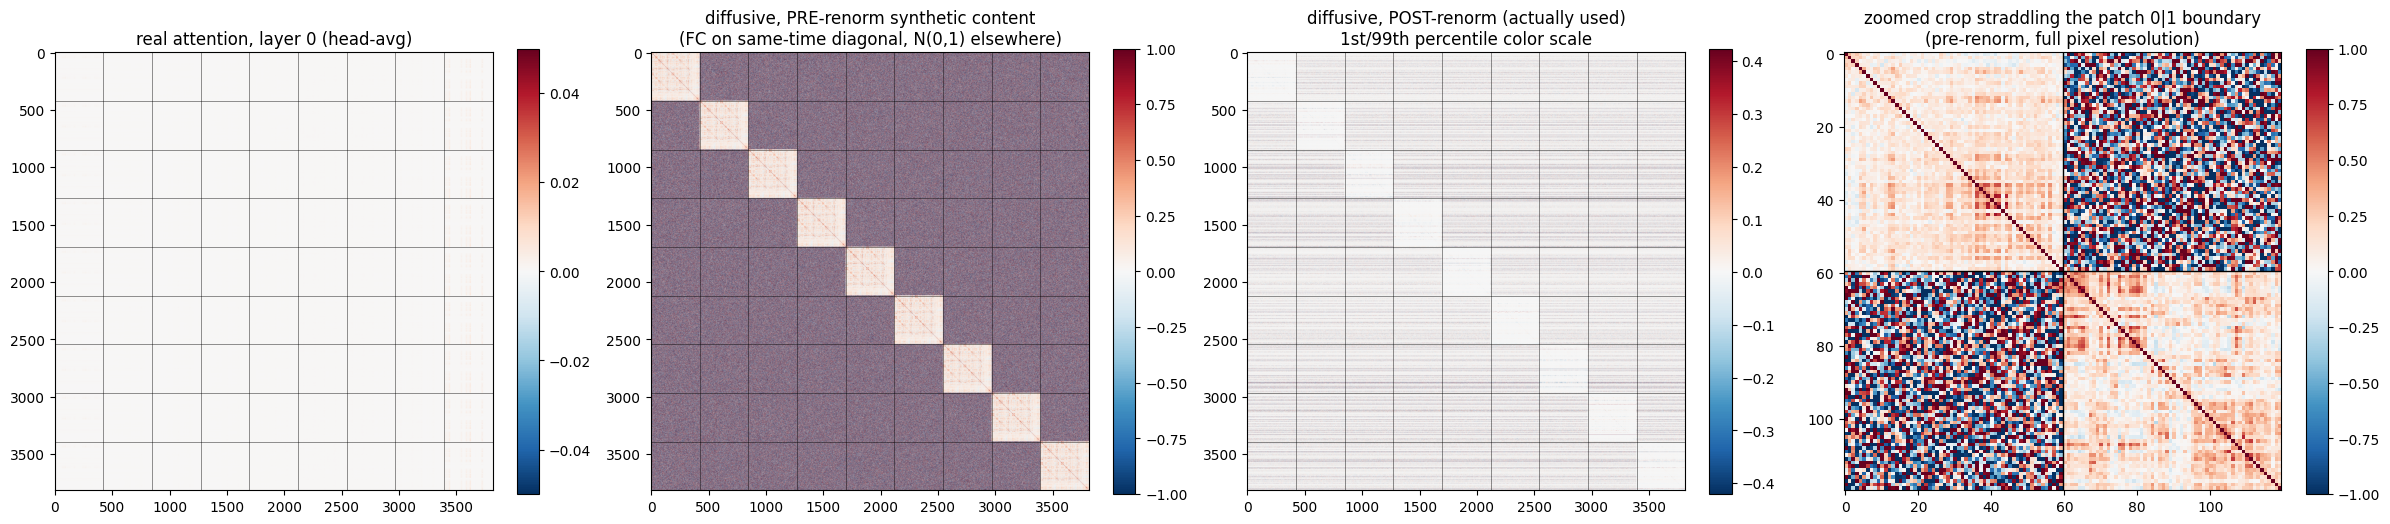

Expect: middle panel shows a clean block-diagonal resembling FC (smoothly varying, correlated with fc_matrix) and unstructured, higher-variance noise everywhere else -- including the positions immediately adjacent to the diagonal blocks, which are now noise too (see the rightmost zoomed panel: a checkerboard, not two smooth blocks side by side). The right panel (what the forward pass actually uses) can look dominated by a few extreme rows/stripes even with a robust color scale -- this is a real consequence of plain signed row-sum renormalization over mostly-unbounded N(0,1) noise (row sums can be small or even near-zero, blowing up that row's scale on division), not a placement bug.

Empirical homotopic-like separation distance in fc_matrix: region-index lag 180 has the highest mean |FC| (0.342) among all off-diagonal lags (for reference, num_regions/2 = 212). This is a REGION-index offset, not a time-patch offset -- it's already fully present in every same-time diagonal block above, s

In [53]:
order = np.lexsort((region_of_check, patch_of_check))  # sort by patch (primary), then region
reordered_idx_incl_cls = order + 1  # +1 for CLS offset -- indexes into the [1+len_keep] attention dim
reordered_idx_no_cls = order        # indexes into the [len_keep] pre-renorm-diagnostic (no CLS row/col stored)

def reorder(mat2d, idx):
    return mat2d[np.ix_(idx, idx)]

attn_real_l0 = out_before.attentions[0][0].mean(dim=0).cpu().numpy()          # head-averaged, layer 0, no hook
attn_diffusive_l0 = out_diffusive.attentions[0][0].mean(dim=0).cpu().numpy()  # head-averaged, layer 0, diffusive (post-renorm, actually used in the forward pass)
preranorm_l0 = layer_diag_viz[0]["modified_preranorm_head0"][1:, 1:]          # pre-renorm synthetic content only, CLS row/col dropped (same for every head)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
im0 = axes[0].imshow(reorder(attn_real_l0, reordered_idx_incl_cls), cmap="RdBu_r", vmin=-0.05, vmax=0.05)
axes[0].set_title("real attention, layer 0 (head-avg)")
im1 = axes[1].imshow(reorder(preranorm_l0, reordered_idx_no_cls), cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title("diffusive, PRE-renorm synthetic content\n(FC on same-time diagonal, N(0,1) elsewhere)")
p1, p99 = np.percentile(reorder(attn_diffusive_l0, reordered_idx_incl_cls), [1, 99])
im2 = axes[2].imshow(reorder(attn_diffusive_l0, reordered_idx_incl_cls), cmap="RdBu_r", vmin=p1, vmax=p99)
axes[2].set_title("diffusive, POST-renorm (actually used)\n1st/99th percentile color scale")

boundaries = np.cumsum(block_sizes)[:-1]
for ax in axes[:3]:
    for b in boundaries:
        ax.axhline(b - 0.5, color="black", linewidth=0.5, alpha=0.6)
        ax.axvline(b - 0.5, color="black", linewidth=0.5, alpha=0.6)

# Zoomed crop straddling one block boundary (patch 0 | patch 1), PRE-renorm, at full pixel
# resolution (no downsampling-induced aliasing of the high-frequency N(0,1) noise into a flat
# gray/purple tone): should show a checkerboard -- smooth, FC-derived diagonal quadrants
# (patch0-patch0 top-left, patch1-patch1 bottom-right) against noisy off-diagonal quadrants
# (patch0-patch1 and patch1-patch0), with a crisp boundary right at the patch split -- NOT two
# smooth FC quadrants side by side, which is what the earlier (incorrect) version of this hook
# would have shown here.
crop_lo, crop_hi = block_sizes[0] - 60, block_sizes[0] + 60
preranorm_l0_reordered = reorder(preranorm_l0, reordered_idx_no_cls)
im3 = axes[3].imshow(preranorm_l0_reordered[crop_lo:crop_hi, crop_lo:crop_hi], cmap="RdBu_r", vmin=-1, vmax=1)
axes[3].axhline(60 - 0.5, color="black", linewidth=1)
axes[3].axvline(60 - 0.5, color="black", linewidth=1)
axes[3].set_title("zoomed crop straddling the patch 0|1 boundary\n(pre-renorm, full pixel resolution)")

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.colorbar(im2, ax=axes[2], fraction=0.046)
fig.colorbar(im3, ax=axes[3], fraction=0.046)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_diffusive_block_grid_heatmap.png"), dpi=130, bbox_inches="tight")
plt.show()

print("Expect: middle panel shows a clean block-diagonal resembling FC (smoothly varying, "
      "correlated with fc_matrix) and unstructured, higher-variance noise everywhere else -- "
      "including the positions immediately adjacent to the diagonal blocks, which are now "
      "noise too (see the rightmost zoomed panel: a checkerboard, not two smooth blocks side "
      "by side). The right panel (what the forward pass actually uses) can look dominated by "
      "a few extreme rows/stripes even with a robust color scale -- this is a real consequence "
      "of plain signed row-sum renormalization over mostly-unbounded N(0,1) noise (row sums can "
      "be small or even near-zero, blowing up that row's scale on division), not a placement bug.")

# Where does the real homotopic band actually sit? Report the lag k (in REGION-index units,
# not time-patch units) that maximizes mean off-diagonal FC magnitude -- this is the real
# separation distance the diagonal-block substitution above preserves automatically, simply by
# inserting the complete, real fc_matrix rather than any synthetic approximation of it.
lags = np.arange(1, num_regions)
mean_abs_offdiag = np.array([np.mean(np.abs(np.diag(fc_matrix, k))) for k in lags])
best_lag = int(lags[np.argmax(mean_abs_offdiag)])
print(f"\nEmpirical homotopic-like separation distance in fc_matrix: region-index lag {best_lag} "
      f"has the highest mean |FC| ({mean_abs_offdiag.max():.3f}) among all off-diagonal lags "
      f"(for reference, num_regions/2 = {num_regions / 2:.0f}). This is a REGION-index offset, "
      "not a time-patch offset -- it's already fully present in every same-time diagonal block "
      "above, since those blocks are the complete real fc_matrix.")

In [54]:
attn_diffusive_l0_heads = out_diffusive.attentions[0][0]  # [heads, seq, seq]
non_cls = attn_diffusive_l0_heads[:, 1:, 1:]  # exclude CLS row/col -- CLS itself is real, per-head-varying attention
h0 = non_cls[0]
max_head_diff = max(torch.abs(non_cls[h] - h0).max().item() for h in range(1, non_cls.shape[0]))
print(f"max abs difference between any head and head 0, restricted to non-CLS entries: {max_head_diff:.2e}")
assert max_head_diff < 1e-5, "heads disagree on the non-CLS attention entries -- broadcasting bug"
print("Head-broadcast invariance confirmed: every head has the identical substituted (FC+noise) "
      "attention outside the CLS row/column -- averaging over heads changes nothing there, as required.")

max abs difference between any head and head 0, restricted to non-CLS entries: 0.00e+00
Head-broadcast invariance confirmed: every head has the identical substituted (FC+noise) attention outside the CLS row/column -- averaging over heads changes nothing there, as required.


In [55]:
row0_diff = np.abs(layer_diag_viz[0]["row0_after"] - layer_diag_viz[0]["row0_before"]).max()
col0_diff = np.abs(layer_diag_viz[0]["col0_after"] - layer_diag_viz[0]["col0_before"]).max()
print(f"layer 0: CLS row (query=CLS) max abs change after substitution: {row0_diff:.2e} (expected exactly 0)")
print(f"layer 0: CLS column (key=CLS, i.e. every other token's attention TO the CLS token) "
      f"max abs change: {col0_diff:.2e} (expected exactly 0)")
print("Both are excluded from the block-assignment loop AND from the renormalization sum "
      "(see make_diffusive_fc_attention_hook's renormalization comment) -- unlike the "
      "single-layer notebook's hook, which rescales column 0 along with the rest of each "
      "row, this hook leaves the CLS row and column completely untouched, at the cost of "
      "each substituted row's true total being a hair above/below 1.")
assert row0_diff == 0.0, "CLS row (query) changed -- the block-assignment loop or renorm may be touching index 0"
assert col0_diff == 0.0, "CLS column (key) changed -- the renorm may be including column 0 in some row's denominator"
print("CLS-row/column-untouched check passed.")

layer 0: CLS row (query=CLS) max abs change after substitution: 0.00e+00 (expected exactly 0)
layer 0: CLS column (key=CLS, i.e. every other token's attention TO the CLS token) max abs change: 0.00e+00 (expected exactly 0)
Both are excluded from the block-assignment loop AND from the renormalization sum (see make_diffusive_fc_attention_hook's renormalization comment) -- unlike the single-layer notebook's hook, which rescales column 0 along with the rest of each row, this hook leaves the CLS row and column completely untouched, at the cost of each substituted row's true total being a hair above/below 1.
CLS-row/column-untouched check passed.


In [56]:
pre_renorm = layer_diag_viz[0]["row_sums_pre_renorm"][:, :, 1:]  # row 0's entry is unused/meaningless, see hook docstring
neg_rows = int((pre_renorm < 0).sum())
print(f"layer 0: pre-renorm synthetic-row sums (substituted rows only) -- min={pre_renorm.min():.4f}, "
      f"max={pre_renorm.max():.4f}, negative rows={neg_rows}/{pre_renorm.size} "
      "(each one flips that row's synthetic entries' sign on division -- an accepted caveat of "
      "plain signed row-sum renormalization, expected to be more common here than in the "
      "single-diagonal-block case since N(0,1) noise can push row sums further from anything "
      "well-behaved; note this can no longer corrupt the untouched, real CLS-column entry, "
      "unlike the single-layer notebook's hook)")

layer 0: pre-renorm synthetic-row sums (substituted rows only) -- min=-170.8511, max=235.7901, negative rows=4388/15264 (each one flips that row's synthetic entries' sign on division -- an accepted caveat of plain signed row-sum renormalization, expected to be more common here than in the single-diagonal-block case since N(0,1) noise can push row sums further from anything well-behaved; note this can no longer corrupt the untouched, real CLS-column entry, unlike the single-layer notebook's hook)


In [57]:
diag_l0 = layer_diag_viz[0]["diag_block_t0_preranorm"]
diag_l1 = layer_diag_viz[1]["diag_block_t0_preranorm"]
same_fc_block = np.allclose(diag_l0, diag_l1)
print(f"diagonal FC block (patch 0) identical across layer 0 and layer 1 (pre-renormalization): {same_fc_block}")
assert same_fc_block, "FC-derived block differs across layers -- should be deterministic (same fc_matrix, same kept indices)"

rs_l0 = layer_diag_viz[0]["row_sums_pre_renorm"]
rs_l1 = layer_diag_viz[1]["row_sums_pre_renorm"]
frac_rows_differing = float((np.abs(rs_l0 - rs_l1) > 1e-6).mean())
print(f"fraction of rows whose pre-renorm sum differs between layer 0 and layer 1: {frac_rows_differing:.3f} "
      "(expected close to 1.0 -- every row's sum includes layer-specific Gaussian noise entries, "
      "so different layer_seed draws should make almost every row sum differ)")
assert frac_rows_differing > 0.9, "row sums barely differ across layers -- are layers accidentally sharing one RNG stream?"
print("Per-layer independence check passed: FC-derived blocks match across layers, noise-driven row sums do not.")

diagonal FC block (patch 0) identical across layer 0 and layer 1 (pre-renormalization): True
fraction of rows whose pre-renorm sum differs between layer 0 and layer 1: 1.000 (expected close to 1.0 -- every row's sum includes layer-specific Gaussian noise entries, so different layer_seed draws should make almost every row sum differ)
Per-layer independence check passed: FC-derived blocks match across layers, noise-driven row sums do not.


In [58]:
import time
t0 = time.time()
_ = predict_exact_patches_fc_diffused(model, x, spatial_coords, future_mask_indices, fc_matrix,
                                       num_regions, num_patches, subject_index=SUBJECT_INDEX)
elapsed_one = time.time() - t0
print(f"one predict_exact_patches_fc_diffused call: {elapsed_one:.2f}s")
print(f"extrapolated for {N_SUBJECTS_MULTI} subjects x 2 conditions (future+random): "
      f"~{elapsed_one * N_SUBJECTS_MULTI * 2 / 60:.1f} minutes "
      "(does not include per-subject data loading/FC computation overhead)")

one predict_exact_patches_fc_diffused call: 7.55s
extrapolated for 25 subjects x 2 conditions (future+random): ~6.3 minutes (does not include per-subject data loading/FC computation overhead)


In [59]:
DIFFUSIVENESS = 1.0  # 1.0 = fully synthetic (used everywhere else in this notebook); 0.0 = untouched real attention

identity_noise = (torch.arange(seq_len, dtype=torch.float32) / seq_len).unsqueeze(0).to(device)
kept_idx_full = np.arange(seq_len)  # unmasked -> identity permutation, every token kept
region_of_full = kept_idx_full // num_patches
patch_of_full = kept_idx_full % num_patches
order_full = np.lexsort((region_of_full, patch_of_full))  # sort by patch (primary), then region
reordered_idx_full = order_full + 1  # +1 for CLS offset

original_mask_ratio = model.config.mask_ratio
model.config.mask_ratio = 0.0
try:
    with torch.no_grad():
        out_before_full = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=identity_noise)

    layer_diag_full = [dict() for _ in range(model.config.num_hidden_layers)]
    handles_full = install_diffusive_hooks(model, fc_matrix, kept_idx_full, num_patches,
                                            subject_index=SUBJECT_INDEX, diffusiveness=DIFFUSIVENESS,
                                            layer_diagnostics=layer_diag_full)
    try:
        with torch.no_grad():
            out_diffusive_full = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=identity_noise)
    finally:
        remove_all(handles_full)
finally:
    model.config.mask_ratio = original_mask_ratio  # restore MASK_RATIO for the rest of the notebook

num_layers_plot = model.config.num_hidden_layers
print(f"diffusiveness={DIFFUSIVENESS}: unmasked forward passes complete for {num_layers_plot} layers "
      "(real, hook-free, and diffusive, hooked).")
print(f"model.config.mask_ratio restored to {model.config.mask_ratio} for the rest of the notebook.")

diffusiveness=1.0: unmasked forward passes complete for 4 layers (real, hook-free, and diffusive, hooked).
model.config.mask_ratio restored to 0.1 for the rest of the notebook.


## Hand-made attention reconstruction: FC in the diagonal blocks, noise elsewhere

The hypothesis, stated as a rule over the block grid: the `[4240, 4240]` attention
matrix is a `10 x 10` grid of `424 x 424` submatrices (`num_patches x num_patches`
grid of `num_regions x num_regions` blocks). Every block **on the grid diagonal**
(same time patch) is the subject's FC matrix; every other block is random noise;
the whole thing is normalized; and the noise shrinks with depth (layer 0 noisiest,
last layer noise-free), mimicking a diffusive process running out.

**Should extra FC blocks be placed off the grid diagonal, where the displaced bands
are?** No -- and this was checked rather than assumed (the diagnostic cell below
reproduces it). Two measurements settle it:

1. In the model's natural region-major token order, mean `|attention|` at diagonal
   offsets that are exact multiples of `num_patches` runs 9-95x the overall mean,
   while every non-multiple sits at or *below* average (<= 0.94x). An offset is a
   multiple of `num_patches` exactly when the two tokens share a time patch -- so
   real attention is almost entirely same-time-patch structure, and the off-diagonal
   grid blocks (which are precisely the cross-time-patch pairs) have essentially
   nothing in them.
2. Correlation with real last-layer attention, for three candidate constructions:
   full FC in the diagonal blocks = **0.647**; FC restricted to narrow lag bands =
   0.511; diagonal blocks **plus** displaced cross-time-patch blocks = **0.421**.
   Adding the displaced blocks makes the fit clearly worse.

**The displaced bands are already produced by rule 1 alone.** They are a REGION-lag
feature, not a block-grid displacement: a fixed region-lag `L` sits at the constant
token offset `L * num_patches`, so it appears as one continuous band displaced from
the diagonal. This subject's FC peaks at region-lag 180 (mean `|off-diagonal|` 0.342
vs. 0.119 median -- a sharp 2.9x spike, the homotopic/cross-hemisphere separation),
and real attention independently peaks at exactly offset 1800 = 180 x 10 (31x
background, with lags 179/181 only ~11x). Because each diagonal block gets the
*complete* real FC matrix, that homotopic structure is inserted automatically, at its
true separation -- which is why the displaced bands show up in the bottom row without
being placed there explicitly. They were invisible in earlier versions only because
those plots were drawn in patch-major order, where the band is confined inside each
`424 x 424` block instead of spanning the image.

Noise std is set relative to `mean|FC|` (so FC is always the prominent feature) and
runs to exactly zero at the last layer. The result is row-normalized on `|value|` --
always well-behaved (strictly positive denominator, no sign flips), unlike the actual
hook's signed row-sum division. The color scale must use `vmax = percentile(99.5)`,
not `99`: FC is only ~10% of cells, so a lower percentile lands inside the noise and
washes the image out.

Note this is the **13M** checkpoint: 424 regions x 10 patches x 20 TR = 200 TR, and
the FC substituted into each block is computed on exactly those 200 TR. The
`(1, 4, 3817, 3817)` attention shapes seen elsewhere in this notebook are also 13M,
not the 1TR variant: `mask_ratio = 424/4240 = 0.1` masks 424 tokens, leaving
`4240 - 424 = 3816` kept tokens, `+1` for CLS = 3817.

In [ ]:
# Hand-made attention reconstruction, built in the model's own NATURAL (region-major) token
# order so it is directly comparable to the real-attention row and to
# figures/*_full_attention.png. Rule: every block on the 10x10 grid diagonal (same time patch)
# is the real fc_matrix; every other block is noise. See the markdown for why no extra FC
# blocks are placed off the grid diagonal, and the diagnostic cell below for the evidence.

NOISE_START_FRACTION = 1 / 3   # layer 0 noise std, as a fraction of mean|FC| (higher = more diffuse)
# ...linearly down to exactly 0 at the last layer: "layer 0 noisiest, last layer noise-free".

illustration_rng = np.random.default_rng(RANDOM_SEED)

# In region-major order token i = region * num_patches + patch, so two tokens share a time
# patch exactly when their diagonal offset is a multiple of num_patches -- which is also why a
# fixed region-lag L always sits at the constant offset L * num_patches (the displaced bands).
t_idx = (np.arange(seq_len) % num_patches).astype(np.int64)
r_idx = (np.arange(seq_len) // num_patches).astype(np.int64)
same_time_mask = t_idx[:, None] == t_idx[None, :]      # the 10 grid-diagonal blocks
fc_expanded = fc_matrix[r_idx[:, None], r_idx[None, :]].astype(np.float32)

lags = np.arange(1, num_regions)
mean_abs_offdiag = np.array([np.mean(np.abs(np.diag(fc_matrix, k))) for k in lags])
homotopic_lag = int(lags[np.argmax(mean_abs_offdiag)])
homotopic_offset = homotopic_lag * num_patches

mean_abs_fc = float(np.abs(fc_expanded[same_time_mask]).mean())
noise_scales = np.linspace(mean_abs_fc * NOISE_START_FRACTION, 0.0, num_layers_plot)

print(f"FC occupies {100 * same_time_mask.mean():.1f}% of cells (the 10 grid-diagonal blocks), "
      f"mean|FC| = {mean_abs_fc:.3f}")
print(f"homotopic region-lag = {homotopic_lag} (mean |FC| off-diagonal {mean_abs_offdiag.max():.3f} vs "
      f"{np.median(mean_abs_offdiag):.3f} median) -> displaced band at token offset {homotopic_offset}, "
      "inserted automatically by using the complete fc_matrix")
print(f"noise std per layer: {np.array2string(noise_scales, precision=4)}")


def build_attention_reconstruction(noise_scale, rng):
    """[seq_len, seq_len], natural (region-major) token order. Same-time-patch pairs (the 10
    grid-diagonal 424x424 blocks) get the real fc_matrix; every other pair gets i.i.d.
    N(0, noise_scale**2). Row-normalized on |value| into a non-negative, attention-like matrix."""
    noise = (rng.standard_normal((seq_len, seq_len)) * noise_scale).astype(np.float32)
    raw = np.where(same_time_mask, fc_expanded, noise)
    weights = np.abs(raw)
    row_sums = weights.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1e-12
    return weights / row_sums


fig, axes = plt.subplots(2, num_layers_plot, figsize=(5.5 * num_layers_plot, 10.5))
if num_layers_plot == 1:
    axes = axes.reshape(2, 1)

reconstructions = []  # kept for the diagnostic cell right below
for layer_idx in range(num_layers_plot):
    real_full = out_before_full.attentions[layer_idx][0].mean(dim=0).cpu().numpy()  # real, head-avg
    real_no_cls = real_full[1:, 1:]  # drop CLS only -- natural token order, unchanged

    reconstruction = build_attention_reconstruction(noise_scales[layer_idx], illustration_rng)
    reconstructions.append(reconstruction)

    ax_top, ax_bot = axes[0, layer_idx], axes[1, layer_idx]
    ax_top.imshow(real_no_cls, cmap="magma",
                  vmin=np.percentile(real_no_cls, 1), vmax=np.percentile(real_no_cls, 99))
    # vmax at percentile 99.5, not 99 -- see markdown.
    ax_bot.imshow(reconstruction, cmap="magma", vmin=0, vmax=np.percentile(reconstruction, 99.5))
    ax_top.set_title(f"layer {layer_idx}: REAL attention")
    ax_bot.set_title(f"layer {layer_idx}: reconstruction\n(FC in grid-diagonal blocks, noise std={noise_scales[layer_idx]:.3f})")
    ax_top.set_xticks([]); ax_top.set_yticks([])
    ax_bot.set_xticks([]); ax_bot.set_yticks([])

axes[0, 0].set_ylabel("real attention\n(natural region x time-patch order, unmasked)", fontsize=10)
axes[1, 0].set_ylabel(f"hand-made reconstruction\n(homotopic bands at offset +-{homotopic_offset}, automatic)", fontsize=10)
fig.suptitle(f"{sub_id} -- real attention vs. the hand-made FC-block reconstruction, per layer\n"
             f"FC in all 10 grid-diagonal blocks, noise elsewhere shrinking to zero by the last layer", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_real_vs_fc_block_reconstruction_by_layer.png"),
            dpi=130, bbox_inches="tight")
plt.show()


In [ ]:
# Evidence for the construction above -- run live so none of it has to be taken on faith.
# The reconstruction is built purely from fc_matrix + independent noise and never reads
# out_before_full, so any resemblance to real attention comes from the FC placement itself.

real_last = out_before_full.attentions[-1][0].mean(dim=0).cpu().numpy()[1:, 1:]
overall = real_last.mean()
rows = np.arange(seq_len)


def offset_ratio(mat, offset):
    ok = rows + offset < seq_len
    return mat[rows[ok], rows[ok] + offset].mean() / mat.mean()


# 1. Where real attention's structure actually lives: same-time-patch (offsets that are
#    multiples of num_patches) vs. cross-time-patch (everything else, i.e. the off-diagonal
#    blocks of the 10x10 grid). This is what decides whether to put FC off the grid diagonal.
print("Real attention, mean |value| relative to its overall mean:")
for layer_idx in range(num_layers_plot):
    rl = out_before_full.attentions[layer_idx][0].mean(dim=0).cpu().numpy()[1:, 1:]
    print(f"  layer {layer_idx}: same-time-patch (grid diagonal)={rl[same_time_mask].mean() / rl.mean():6.2f}x   "
          f"cross-time-patch (off-diagonal blocks)={rl[~same_time_mask].mean() / rl.mean():5.2f}x")
print("  -> cross-time-patch is at or below background, so the off-diagonal grid blocks get noise, not FC.")

# 2. The displaced band is a REGION-lag feature, present automatically: compare real attention
#    at the homotopic offset against a control region-lag in neither band.
CONTROL_LAG = 90
print(f"\nReal attention at specific region-lags (last layer), relative to overall mean:")
print(f"  homotopic lag {homotopic_lag} (offset {homotopic_offset}): {offset_ratio(real_last, homotopic_offset):6.2f}x")
print(f"  control   lag {CONTROL_LAG} (offset {CONTROL_LAG * num_patches}): {offset_ratio(real_last, CONTROL_LAG * num_patches):6.2f}x")
print(f"  -> the lag was derived from fc_matrix alone, yet lands on real attention's own peak.")

# 3. Correlation with real attention for three candidate constructions, at matched noise, to
#    justify NOT adding displaced FC blocks off the grid diagonal.
region_lag = r_idx[None, :] - r_idx[:, None]
t_diff = t_idx[None, :] - t_idx[:, None]
BLOCK_OFFSET = int(round(homotopic_offset / num_regions))  # nearest whole-block displacement
candidates = {
    "FC in grid-diagonal blocks (used above)": same_time_mask,
    "FC restricted to narrow lag bands": same_time_mask & ((np.abs(region_lag) <= 20) |
                                                           (np.abs(np.abs(region_lag) - homotopic_lag) <= 2)),
    f"grid-diagonal + displaced blocks |t'-t|={BLOCK_OFFSET}": same_time_mask | (np.abs(t_diff) == BLOCK_OFFSET),
}
check_rng = np.random.default_rng(RANDOM_SEED)
print("\nCorrelation with real last-layer attention (matched low noise):")
for name, region in candidates.items():
    scale = float(np.abs(fc_expanded[region]).mean()) / 30.0
    noise = (check_rng.standard_normal((seq_len, seq_len)) * scale).astype(np.float32)
    w = np.abs(np.where(region, fc_expanded, noise))
    w /= w.sum(axis=1, keepdims=True)
    print(f"  {name:52s} FC cells={100 * region.mean():5.1f}%  corr={np.corrcoef(real_last.ravel(), w.ravel())[0, 1]:.3f}")
print("  -> adding displaced cross-time-patch blocks makes the fit worse, consistent with (1).")

print("\nLeak check -- the reconstruction is independent of real attention by construction; "
      "its correlation comes from FC placement alone:")
offdiag = ~np.eye(seq_len, dtype=bool)
for layer_idx in range(num_layers_plot):
    rl = out_before_full.attentions[layer_idx][0].mean(dim=0).cpu().numpy()[1:, 1:]
    rec = reconstructions[layer_idx]
    print(f"  layer {layer_idx} (noise std={noise_scales[layer_idx]:.3f}): corr={np.corrcoef(rl.ravel(), rec.ravel())[0, 1]:.3f} "
          f"(excluding the trivial self-attention diagonal: {np.corrcoef(rl[offdiag], rec[offdiag])[0, 1]:.3f})")


## What the actual hook-injected substitution looks like, structurally

The previous section's plot is a fresh, purely illustrative construction (fc_matrix
on the diagonal, noise shrinking layer-by-layer) built just for that figure -- it
does not draw on what `make_diffusive_fc_attention_hook` actually injects into the
model. This section instead shows the literal, constant-`DIFFUSIVENESS` construction
the hooks build and the forward pass actually used above (`layer_diag_full`,
pre-renormalization), with no time-averaging: the full attention matrix, real (top
row) vs. the FC-diagonal + noise construction (bottom row), for every layer,
reordered by (patch, region) so the same-time-patch diagonal blocks line up
visually. Reuses the same unmasked forward passes computed above -- no need to
recompute.


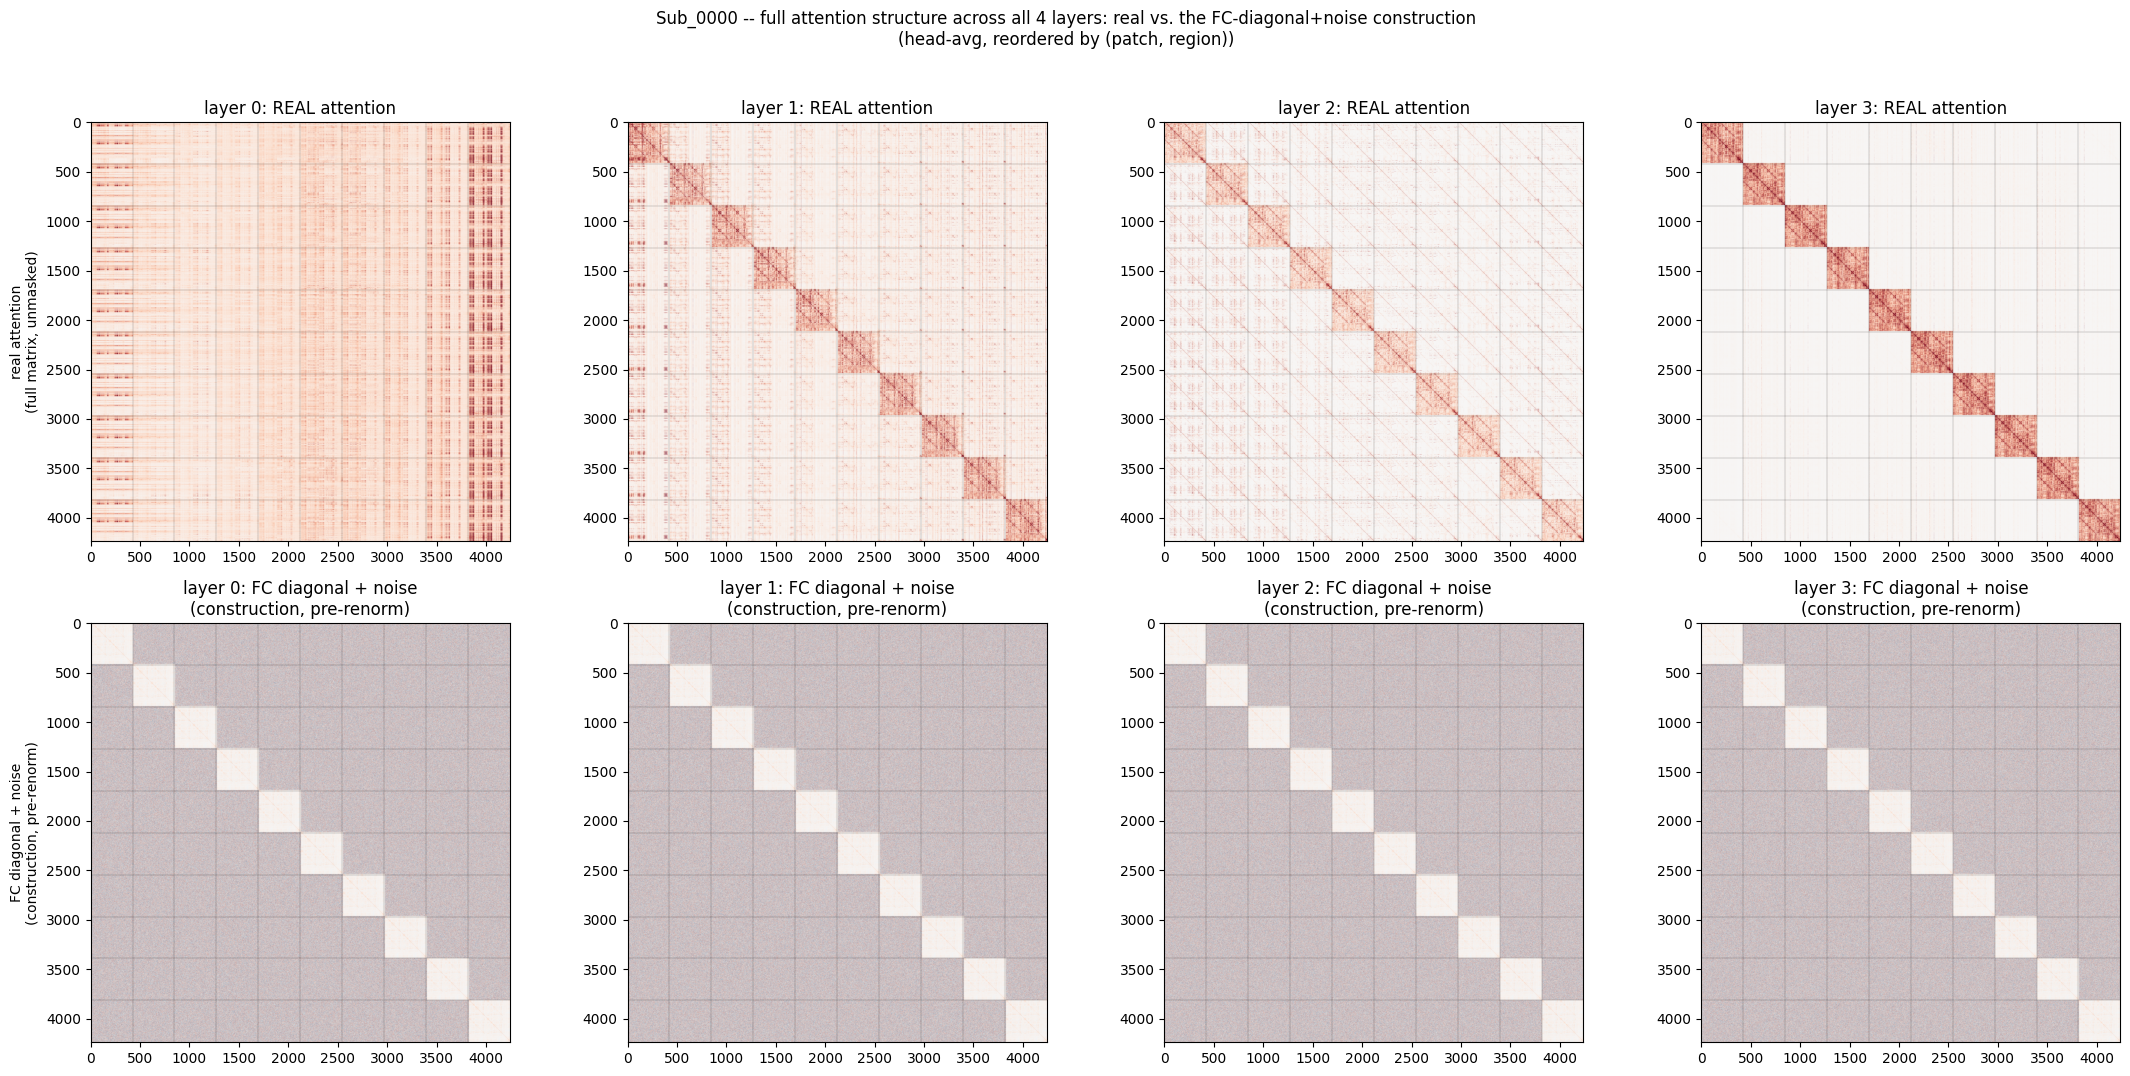

Bottom row should show a clean grid of same-time diagonal blocks resembling FC, and unstructured noise everywhere else -- this is literally what make_diffusive_fc_attention_hook builds, before the row-sum renormalization (next section) rescales it and before time-averaging (also next section) dilutes it against the 9-out-of-10 noise blocks.


In [19]:
def reorder_full(mat2d, idx):
    return mat2d[np.ix_(idx, idx)]

boundaries = np.cumsum([num_regions] * num_patches)[:-1]  # unmasked -> every block is exactly num_regions=424

fig, axes = plt.subplots(2, num_layers_plot, figsize=(5.5 * num_layers_plot, 10.5))
if num_layers_plot == 1:
    axes = axes.reshape(2, 1)

for layer_idx in range(num_layers_plot):
    real_full = out_before_full.attentions[layer_idx][0].mean(dim=0).cpu().numpy()          # real, head-avg
    diffusive_pre_full = layer_diag_full[layer_idx]["modified_preranorm_head0"]              # FC diag + noise, pre-renorm, one head (all heads identical here)

    real_reordered = reorder_full(real_full, reordered_idx_full)
    diffusive_reordered = reorder_full(diffusive_pre_full, reordered_idx_full)

    # separate per-panel color scales -- real attention and the FC+noise construction are on
    # very different natural scales (real attention ~1/seq_len, FC/noise are O(1)).
    vlim_real = np.percentile(np.abs(real_reordered), 99)
    vlim_diffusive = np.percentile(np.abs(diffusive_reordered), 99)

    ax_top, ax_bot = axes[0, layer_idx], axes[1, layer_idx]
    ax_top.imshow(real_reordered, cmap="RdBu_r", vmin=-vlim_real, vmax=vlim_real)
    ax_bot.imshow(diffusive_reordered, cmap="RdBu_r", vmin=-vlim_diffusive, vmax=vlim_diffusive)
    ax_top.set_title(f"layer {layer_idx}: REAL attention")
    ax_bot.set_title(f"layer {layer_idx}: FC diagonal + noise\n(construction, pre-renorm)")

    for ax in (ax_top, ax_bot):
        for b in boundaries:
            ax.axhline(b - 0.5, color="black", linewidth=0.3, alpha=0.4)
            ax.axvline(b - 0.5, color="black", linewidth=0.3, alpha=0.4)

axes[0, 0].set_ylabel("real attention\n(full matrix, unmasked)", fontsize=10)
axes[1, 0].set_ylabel("FC diagonal + noise\n(construction, pre-renorm)", fontsize=10)
fig.suptitle(f"{sub_id} -- full attention structure across all {num_layers_plot} layers: real vs. the "
             "FC-diagonal+noise construction\n(head-avg, reordered by (patch, region))", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_real_vs_construction_full_matrix_by_layer.png"),
            dpi=130, bbox_inches="tight")
plt.show()

print("Bottom row should show a clean grid of same-time diagonal blocks resembling FC, and "
      "unstructured noise everywhere else -- this is literally what make_diffusive_fc_attention_hook "
      "builds, before the row-sum renormalization (next section) rescales it and before time-averaging "
      "(also next section) dilutes it against the 9-out-of-10 noise blocks.")

## Single subject (Sub_0000): future vs. random, diffusive (all-layer FC+noise) attention

In [20]:
pred_future, mask_future = predict_exact_patches_fc_diffused(
    model, x, spatial_coords, future_mask_indices, fc_matrix, num_regions, num_patches, subject_index=SUBJECT_INDEX)

rng = np.random.default_rng(RANDOM_SEED)
random_patch_per_region = rng.integers(0, num_patches, size=num_regions)
random_mask_indices = [token_index(r, int(p), num_patches) for r, p in enumerate(random_patch_per_region)]
pred_random, mask_random = predict_exact_patches_fc_diffused(
    model, x, spatial_coords, random_mask_indices, fc_matrix, num_regions, num_patches, subject_index=SUBJECT_INDEX)

r_future, patch_future = per_region_patch_correlation(pred_future, mask_future, raw_window, patch_size)
r_random, patch_random = per_region_patch_correlation(pred_random, mask_random, raw_window, patch_size)

print(f"{sub_id}, window {WINDOW_INDEX} (TR 0-{WINDOW_SIZE})")
print(f"  future : mean r={np.nanmean(r_future):.3f}, median r={np.nanmedian(r_future):.3f}, std={np.nanstd(r_future):.3f}")
print(f"  random : mean r={np.nanmean(r_random):.3f}, median r={np.nanmedian(r_random):.3f}, std={np.nanstd(r_random):.3f}")

Sub_0000, window 0 (TR 0-200)
  future : mean r=-0.014, median r=-0.018, std=0.247
  random : mean r=0.022, median r=0.019, std=0.300


### Visual sanity check: best-reconstructed regions per condition

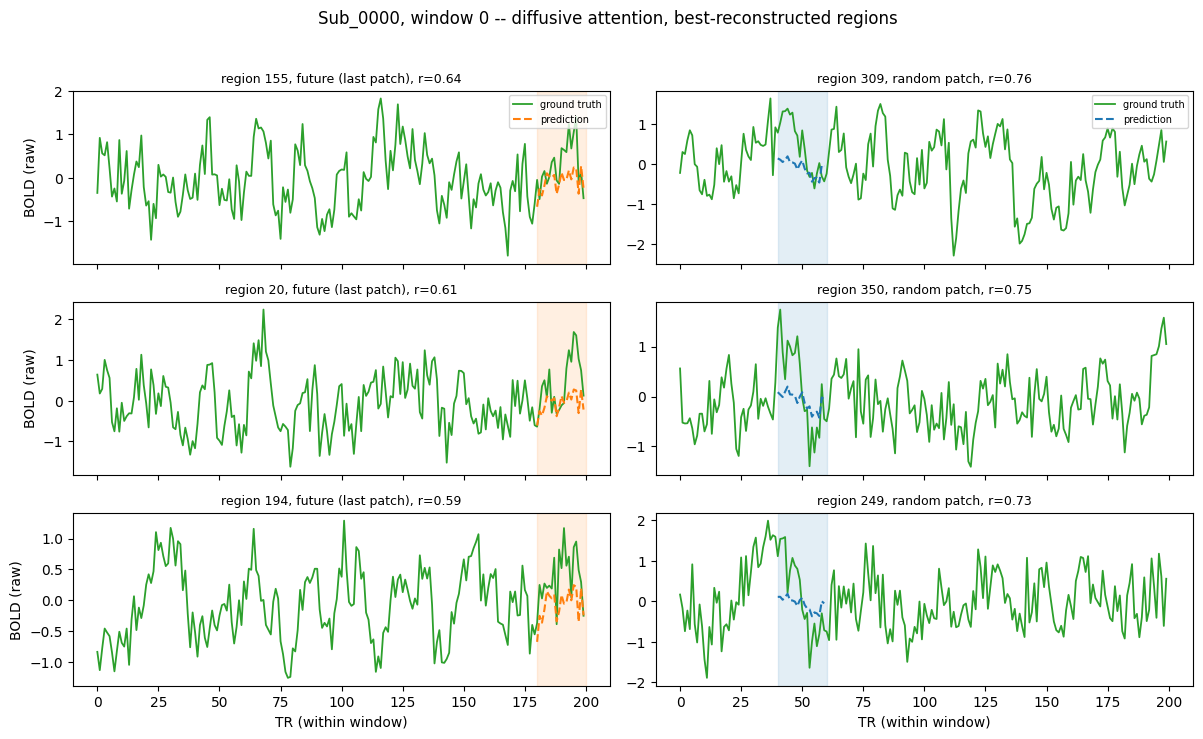

In [21]:
conditions = [
    ("future (last patch)", pred_future, patch_future, r_future, "tab:orange"),
    ("random patch", pred_random, patch_random, r_random, "tab:blue"),
]

top_regions_per_condition = [
    np.argsort(np.nan_to_num(r_vals, nan=-np.inf))[-N_EXAMPLES_PER_CONDITION:][::-1]
    for (_, _, _, r_vals, _) in conditions
]

fig, axes = plt.subplots(N_EXAMPLES_PER_CONDITION, 2, figsize=(12, 2.4 * N_EXAMPLES_PER_CONDITION), sharex=True)

for col, ((label, pred, patch_pos, r_vals, color), top_regions) in enumerate(zip(conditions, top_regions_per_condition)):
    for row, region in enumerate(top_regions):
        ax = axes[row, col]
        ax.plot(raw_window[region], color="tab:green", linewidth=1.3, label="ground truth")
        patch = patch_pos[region]
        tr_lo, tr_hi = patch * patch_size, (patch + 1) * patch_size
        ax.plot(range(tr_lo, tr_hi), pred[region, patch, :], color=color, linewidth=1.5,
                linestyle="--", label="prediction")
        ax.axvspan(tr_lo, tr_hi, color=color, alpha=0.12)
        ax.set_title(f"region {region}, {label}, r={r_vals[region]:.2f}", fontsize=9)
        if row == 0:
            ax.legend(fontsize=7, loc="upper right")
        if col == 0:
            ax.set_ylabel("BOLD (raw)")

axes[-1, 0].set_xlabel("TR (within window)")
axes[-1, 1].set_xlabel("TR (within window)")
fig.suptitle(f"{sub_id}, window {WINDOW_INDEX} -- diffusive attention, best-reconstructed regions", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_w{WINDOW_INDEX}_fc_diffusive_best_examples.png"), dpi=130, bbox_inches="tight")
plt.show()

### Distribution comparison (single subject, all regions)

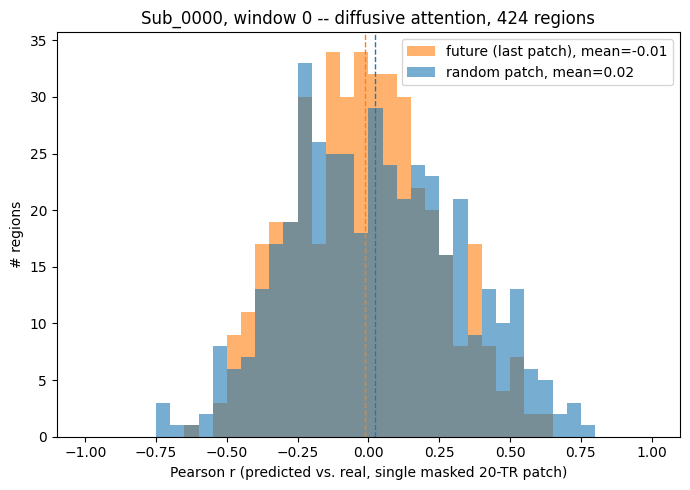

Paired Wilcoxon signed-rank (future vs. random, same regions, n=424): statistic=40468.0, p=0.06955


In [22]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
bins = np.linspace(-1, 1, 41)
ax.hist(r_future, bins=bins, alpha=0.6, color="tab:orange", label=f"future (last patch), mean={np.nanmean(r_future):.2f}")
ax.hist(r_random, bins=bins, alpha=0.6, color="tab:blue", label=f"random patch, mean={np.nanmean(r_random):.2f}")
ax.axvline(np.nanmean(r_future), color="tab:orange", linestyle="--", linewidth=1)
ax.axvline(np.nanmean(r_random), color="tab:blue", linestyle="--", linewidth=1)
ax.set_xlabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
ax.set_ylabel("# regions")
ax.set_title(f"{sub_id}, window {WINDOW_INDEX} -- diffusive attention, {num_regions} regions")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_w{WINDOW_INDEX}_fc_diffusive_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

valid = ~(np.isnan(r_future) | np.isnan(r_random))
stat, p = stats.wilcoxon(r_future[valid], r_random[valid])
print(f"Paired Wilcoxon signed-rank (future vs. random, same regions, n={int(valid.sum())}): statistic={stat:.1f}, p={p:.4g}")

## Multi-subject pooled comparison

Same procedure for the first `N_SUBJECTS_MULTI` subjects, same `RANDOM_SEED +
subject_index` reseeding as the other two notebooks -- so the *same* patches get
masked everywhere, making all three-way comparisons apples-to-apples.

In [23]:
multi_results = []  # rows: subject_id, region, condition, patch, tr_start, tr_end, r
skipped_subjects = []

for subject_index in range(N_SUBJECTS_MULTI):
    with h5py.File(INPUT_H5, "r") as f:
        sub_id_m = f["subject_ids"][subject_index].decode("utf-8")
        raw_data_m = f["parcel_ts"][subject_index, :, :]

    if np.isnan(raw_data_m[:WINDOW_SIZE, :]).any():
        skipped_subjects.append(sub_id_m)
        print(f"{sub_id_m}: skipped (NaNs in first {WINDOW_SIZE} TRs)")
        continue

    fmri_windows_m = preprocess_subject_data(raw_data_m, num_windows=NUM_WINDOWS, window_size=WINDOW_SIZE)
    x_m = fmri_windows_m[WINDOW_INDEX : WINDOW_INDEX + 1].to(device)
    raw_window_m = raw_data_m[:WINDOW_SIZE, :].T
    fc_matrix_m = compute_fc(raw_window_m)

    future_idx_m = [token_index(r, FUTURE_PATCH_IDX, num_patches) for r in range(num_regions)]
    rng_m = np.random.default_rng(RANDOM_SEED + subject_index)
    random_patch_m = rng_m.integers(0, num_patches, size=num_regions)
    random_idx_m = [token_index(r, int(p), num_patches) for r, p in enumerate(random_patch_m)]

    pred_future_m, mask_future_m = predict_exact_patches_fc_diffused(
        model, x_m, spatial_coords, future_idx_m, fc_matrix_m, num_regions, num_patches, subject_index=subject_index)
    pred_random_m, mask_random_m = predict_exact_patches_fc_diffused(
        model, x_m, spatial_coords, random_idx_m, fc_matrix_m, num_regions, num_patches, subject_index=subject_index)

    r_future_m, patch_future_m = per_region_patch_correlation(pred_future_m, mask_future_m, raw_window_m, patch_size)
    r_random_m, patch_random_m = per_region_patch_correlation(pred_random_m, mask_random_m, raw_window_m, patch_size)

    for region in range(num_regions):
        for condition, patch_arr, r_arr in [("future", patch_future_m, r_future_m), ("random", patch_random_m, r_random_m)]:
            patch = int(patch_arr[region])
            multi_results.append({
                "subject_id": sub_id_m, "region": region, "condition": condition,
                "patch": patch, "tr_start": patch * patch_size, "tr_end": (patch + 1) * patch_size,
                "r": float(r_arr[region]),
            })

    print(f"{sub_id_m}: future r={np.nanmean(r_future_m):.3f}, random r={np.nanmean(r_random_m):.3f}")

n_ok = N_SUBJECTS_MULTI - len(skipped_subjects)
print(f"\nDone: {n_ok} subjects processed, {len(skipped_subjects)} skipped ({skipped_subjects}).")

Sub_0000: future r=-0.032, random r=-0.002


Sub_0001: future r=-0.005, random r=0.027


Sub_0002: future r=-0.242, random r=0.189


Sub_0004: future r=-0.046, random r=-0.015


Sub_0005: future r=-0.076, random r=0.155


...

Sub_0021: future r=0.055, random r=0.034


Sub_0022: future r=0.018, random r=0.025


Sub_0023: future r=-0.025, random r=-0.022


Sub_0024: future r=0.004, random r=0.041


Sub_0025: future r=-0.155, random r=-0.005

Done: 25 subjects processed, 0 skipped ([]).


### Pooled distribution across all subjects

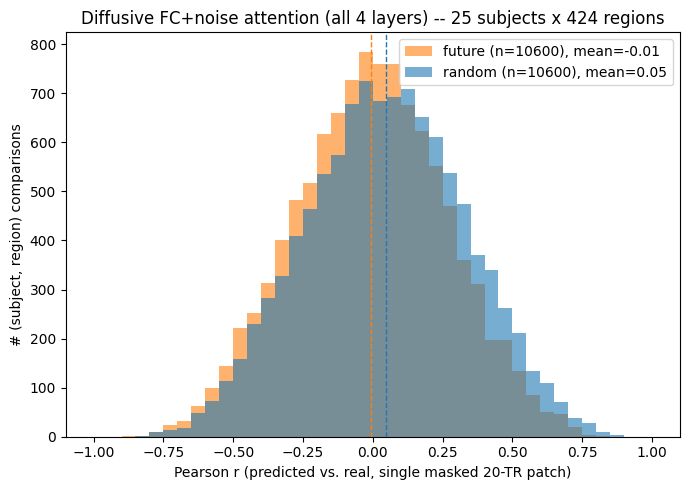

Pooled paired Wilcoxon (future vs. random, n=10600): statistic=24050756.0, p=1.131e-37
future: mean=-0.006, median=-0.003, std=0.272
random: mean=0.046, median=0.047, std=0.285
Saved 21200 rows -> outputs/fc_diffusive_w0_correlations.csv


In [24]:
r_future_all = np.array([row["r"] for row in multi_results if row["condition"] == "future"])
r_random_all = np.array([row["r"] for row in multi_results if row["condition"] == "random"])

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
bins = np.linspace(-1, 1, 41)
ax.hist(r_future_all, bins=bins, alpha=0.6, color="tab:orange", label=f"future (n={len(r_future_all)}), mean={np.nanmean(r_future_all):.2f}")
ax.hist(r_random_all, bins=bins, alpha=0.6, color="tab:blue", label=f"random (n={len(r_random_all)}), mean={np.nanmean(r_random_all):.2f}")
ax.axvline(np.nanmean(r_future_all), color="tab:orange", linestyle="--", linewidth=1)
ax.axvline(np.nanmean(r_random_all), color="tab:blue", linestyle="--", linewidth=1)
ax.set_xlabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
ax.set_ylabel("# (subject, region) comparisons")
ax.set_title(f"Diffusive FC+noise attention (all {model.config.num_hidden_layers} layers) -- {n_ok} subjects x {num_regions} regions")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"multi_subject_w{WINDOW_INDEX}_fc_diffusive_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

valid_all = ~(np.isnan(r_future_all) | np.isnan(r_random_all))
stat_all, p_all = stats.wilcoxon(r_future_all[valid_all], r_random_all[valid_all])
print(f"Pooled paired Wilcoxon (future vs. random, n={int(valid_all.sum())}): statistic={stat_all:.1f}, p={p_all:.4g}")
print(f"future: mean={np.nanmean(r_future_all):.3f}, median={np.nanmedian(r_future_all):.3f}, std={np.nanstd(r_future_all):.3f}")
print(f"random: mean={np.nanmean(r_random_all):.3f}, median={np.nanmedian(r_random_all):.3f}, std={np.nanstd(r_random_all):.3f}")

csv_path = os.path.join(OUTPUTS_DIR, f"fc_diffusive_w{WINDOW_INDEX}_correlations.csv")
with open(csv_path, "w", newline="") as f_out:
    writer = csv.DictWriter(f_out, fieldnames=["subject_id", "region", "condition", "patch", "tr_start", "tr_end", "r"])
    writer.writeheader()
    writer.writerows(multi_results)
print(f"Saved {len(multi_results)} rows -> {csv_path}")

### Per-subject breakdown: is the effect consistent across subjects?

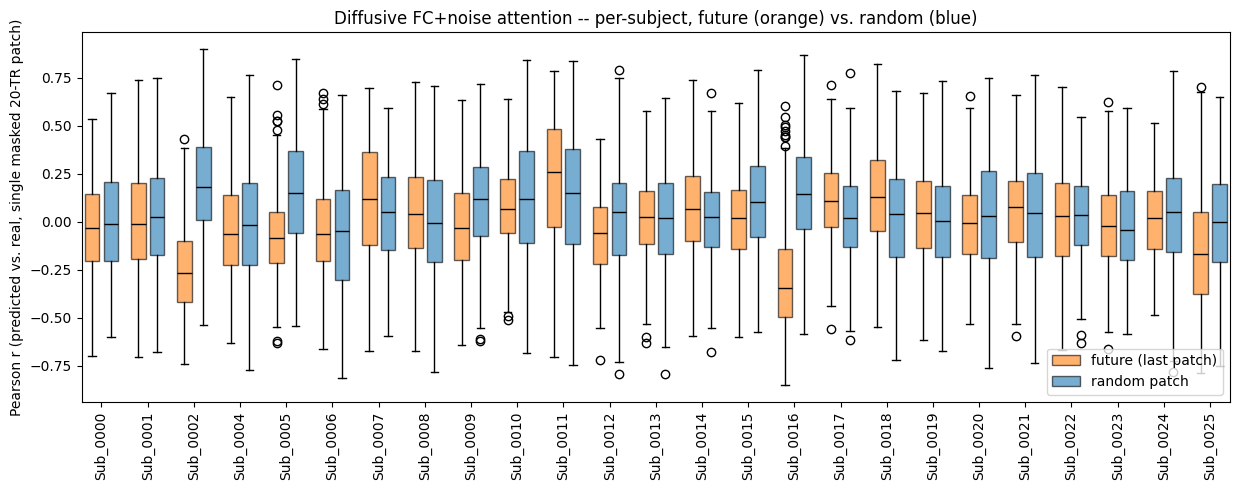

In [25]:
subject_order = list(dict.fromkeys(row["subject_id"] for row in multi_results))

future_by_subject = [[row["r"] for row in multi_results if row["subject_id"] == sid and row["condition"] == "future"]
                      for sid in subject_order]
random_by_subject = [[row["r"] for row in multi_results if row["subject_id"] == sid and row["condition"] == "random"]
                      for sid in subject_order]

positions_future = np.arange(len(subject_order)) * 2.2
positions_random = positions_future + 0.9

fig, ax = plt.subplots(1, 1, figsize=(max(10, len(subject_order) * 0.5), 5))
bp_f = ax.boxplot(future_by_subject, positions=positions_future, widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor="tab:orange", alpha=0.6), medianprops=dict(color="black"))
bp_r = ax.boxplot(random_by_subject, positions=positions_random, widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor="tab:blue", alpha=0.6), medianprops=dict(color="black"))
ax.set_xticks((positions_future + positions_random) / 2)
ax.set_xticklabels(subject_order, rotation=90)
ax.set_ylabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
ax.set_title("Diffusive FC+noise attention -- per-subject, future (orange) vs. random (blue)")
ax.legend([bp_f["boxes"][0], bp_r["boxes"][0]], ["future (last patch)", "random patch"], loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"multi_subject_w{WINDOW_INDEX}_fc_diffusive_per_subject.png"), dpi=130, bbox_inches="tight")
plt.show()

## The actual hypothesis test: original model vs. single-layer FC-substituted vs. diffusive (all-layer FC+noise)

Loads `future_vs_random_w0_correlations.csv` (original, unsubstituted model) and
`fc_substituted_w0_correlations.csv` (single-layer, diagonal-only FC substitution,
filtered to `variant == "fc"` to match this notebook's raw, non-abs renormalization)
-- same subjects, same seeds -> same masked tokens everywhere -- and runs a paired
Wilcoxon test for every pair of the three conditions.


future:
  original model (mean=0.022) vs. diffusive (all layers, FC+noise) (mean=-0.006): paired Wilcoxon n=10600, statistic=26274657.0, p=7.916e-09
  single-layer FC-substituted (mean=0.008) vs. diffusive (all layers, FC+noise) (mean=-0.006): paired Wilcoxon n=10600, statistic=27422528.0, p=0.03343
  original model (mean=0.022) vs. single-layer FC-substituted (mean=0.008): paired Wilcoxon n=10600, statistic=26991538.0, p=0.0004743

random:
  original model (mean=0.159) vs. diffusive (all layers, FC+noise) (mean=0.046): paired Wilcoxon n=10600, statistic=20708082.0, p=1.74e-121
  single-layer FC-substituted (mean=0.347) vs. diffusive (all layers, FC+noise) (mean=0.046): paired Wilcoxon n=10600, statistic=8299552.0, p=0
  original model (mean=0.159) vs. single-layer FC-substituted (mean=0.347): paired Wilcoxon n=10600, statistic=10535659.0, p=0


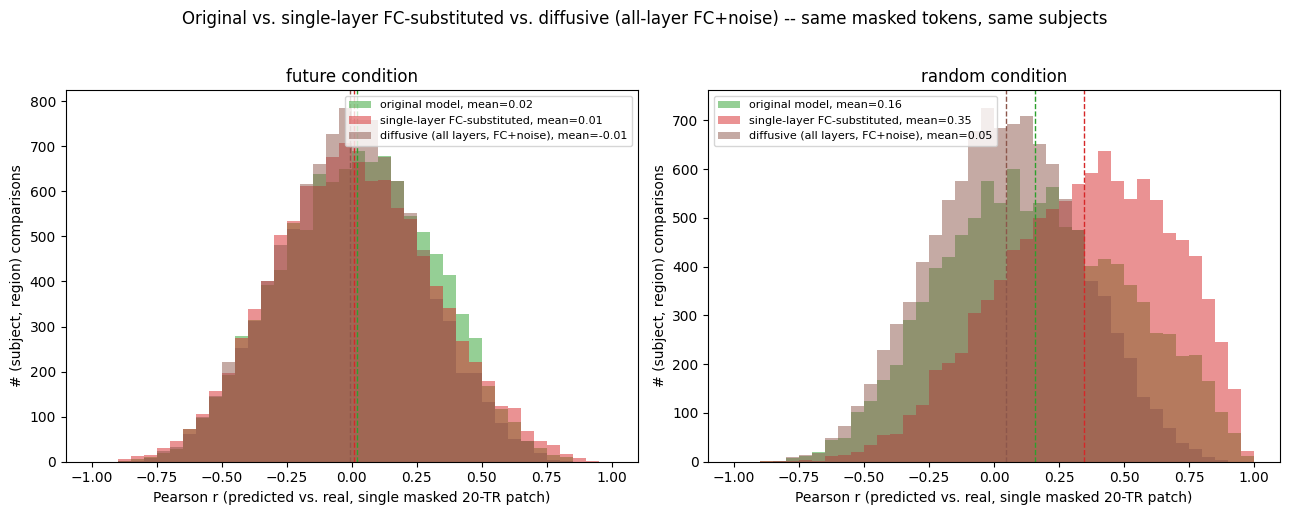

In [26]:
if not os.path.exists(ORIGINAL_MODEL_CSV):
    raise FileNotFoundError(
        f"{ORIGINAL_MODEL_CSV} not found -- run future_vs_random_token_reconstruction.ipynb first "
        "(same RANDOM_SEED, same N_SUBJECTS_MULTI) so there's a same-tokens baseline to compare against."
    )
if not os.path.exists(SINGLE_LAYER_FC_CSV):
    raise FileNotFoundError(
        f"{SINGLE_LAYER_FC_CSV} not found -- run fc_substituted_attention_reconstruction.ipynb first "
        "(same RANDOM_SEED, same N_SUBJECTS_MULTI) so there's a single-layer-FC baseline to compare against."
    )

with open(ORIGINAL_MODEL_CSV, newline="") as f_in:
    original_results = list(csv.DictReader(f_in))
with open(SINGLE_LAYER_FC_CSV, newline="") as f_in:
    single_layer_fc_results = list(csv.DictReader(f_in))

orig_lookup = {(row["subject_id"], int(row["region"]), row["condition"]): float(row["r"]) for row in original_results}
single_fc_lookup = {(row["subject_id"], int(row["region"]), row["condition"]): float(row["r"])
                     for row in single_layer_fc_results if row["variant"] == "fc"}
diffusive_lookup = {(row["subject_id"], row["region"], row["condition"]): float(row["r"]) for row in multi_results}

paired = {c: {"orig": [], "single_fc": [], "diffusive": []} for c in ["future", "random"]}
missing = 0
for key, r_diff in diffusive_lookup.items():
    sub_id_k, region_k, condition_k = key
    key_int = (sub_id_k, int(region_k), condition_k)
    if key_int not in orig_lookup or key_int not in single_fc_lookup:
        missing += 1
        continue
    paired[condition_k]["orig"].append(orig_lookup[key_int])
    paired[condition_k]["single_fc"].append(single_fc_lookup[key_int])
    paired[condition_k]["diffusive"].append(r_diff)

if missing:
    print(f"Note: {missing} (subject, region, condition) rows missing from one of the three sources "
          "(different N_SUBJECTS_MULTI between runs?) -- excluded from the paired comparison.")

COLORS = {"orig": "tab:green", "single_fc": "tab:red", "diffusive": "tab:brown"}
LABELS = {"orig": "original model", "single_fc": "single-layer FC-substituted", "diffusive": "diffusive (all layers, FC+noise)"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = np.linspace(-1, 1, 41)

for ax, condition_k in zip(axes, ["future", "random"]):
    vals = {k: np.array(v) for k, v in paired[condition_k].items()}
    for k in ["orig", "single_fc", "diffusive"]:
        ax.hist(vals[k], bins=bins, alpha=0.5, color=COLORS[k], label=f"{LABELS[k]}, mean={np.nanmean(vals[k]):.2f}")
        ax.axvline(np.nanmean(vals[k]), color=COLORS[k], linestyle="--", linewidth=1)
    ax.set_xlabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
    ax.set_ylabel("# (subject, region) comparisons")
    ax.set_title(f"{condition_k} condition")
    ax.legend(fontsize=8)

    print(f"\n{condition_k}:")
    for a, b in [("orig", "diffusive"), ("single_fc", "diffusive"), ("orig", "single_fc")]:
        valid_pair = ~(np.isnan(vals[a]) | np.isnan(vals[b]))
        stat_pair, p_pair = stats.wilcoxon(vals[a][valid_pair], vals[b][valid_pair])
        print(f"  {LABELS[a]} (mean={np.nanmean(vals[a]):.3f}) vs. {LABELS[b]} (mean={np.nanmean(vals[b]):.3f}): "
              f"paired Wilcoxon n={int(valid_pair.sum())}, statistic={stat_pair:.1f}, p={p_pair:.4g}")

fig.suptitle("Original vs. single-layer FC-substituted vs. diffusive (all-layer FC+noise) -- same masked tokens, same subjects", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"original_vs_single_fc_vs_diffusive_w{WINDOW_INDEX}_comparison.png"), dpi=130, bbox_inches="tight")
plt.show()

## Discussion

If reconstruction quality under the diffusive substitution is close to the
single-layer FC-substituted result, forcing FC on the same-time diagonal plus noise
everywhere else at every layer isn't much more destructive than doing it once at the
last layer -- suggesting the model doesn't rely heavily on attention structure beyond
this FC-like pattern at any depth. If it's substantially worse, the model is relying
on attention patterns further from this FC+noise hypothesis at the earlier layers,
or on cross-time-patch structure (`|t - t'| >= 1`) that this notebook replaces
entirely with noise -- worth following up by keeping the off-diagonal time-patch
blocks "real" and only forcing FC on the same-time diagonal, to isolate which change
actually drives the difference.